# DeepFakeRecognizer AI-Only Validation

This notebook validates `DeepFakeRecognizer` using only the Transformers model (deterministic branch disabled) on the Kaggle dataset `muhammadbilal6305/200k-real-vs-ai-visuals-by-mbilal`.

It is intentionally simple:
- download + extract dataset
- infer labels from folder names
- run `DeepFakeRecognizer` in AI-only mode
- report metrics and confusion matrix

In [1]:
# Uncomment if packages are missing in a fresh Colab runtime
# %pip install -q transformers torch torchvision pillow pandas scikit-learn kaggle tqdm

In [7]:
import json
import os
import sys
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE_DIR = Path('/content') if IN_COLAB else Path.cwd()
DATA_DIR = BASE_DIR / 'data' / 'real-vs-ai-mbilal'
OUTPUT_DIR = BASE_DIR / 'outputs'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_DATASET = 'muhammadbilal6305/200k-real-vs-ai-visuals-by-mbilal'
MODEL_NAME = 'prithivMLmods/Deep-Fake-Detector-v2-Model'
REAL_FOLDER_KEYWORDS = ['real', 'genuine', 'authentic', 'original', 'human']
FAKE_FOLDER_KEYWORDS = ['fake', 'ai', 'generated', 'deepfake', 'synthetic', 'artificial']
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

# Keep this reasonably sized by default. Set to None to run on all labeled images.
MAX_PER_CLASS = 20
SEED = 42
SCORE_THRESHOLD = 0.5

print(f"Runtime: {'Google Colab' if IN_COLAB else 'Local / VS Code'}")
print(f'BASE_DIR: {BASE_DIR}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')
print(f'MAX_PER_CLASS: {MAX_PER_CLASS}')
print(f'CUDA available: {torch.cuda.is_available()}')

Runtime: Local / VS Code
BASE_DIR: c:\Users\kaloy\Documents\repos\fmi\fmicodes\proxy-poc
DATA_DIR: c:\Users\kaloy\Documents\repos\fmi\fmicodes\proxy-poc\data\real-vs-ai-mbilal
OUTPUT_DIR: c:\Users\kaloy\Documents\repos\fmi\fmicodes\proxy-poc\outputs
MAX_PER_CLASS: 20
CUDA available: False


In [8]:
def setup_kaggle_credentials() -> Path:
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    cred_path = kaggle_dir / 'kaggle.json'

    if cred_path.exists():
        os.chmod(cred_path, 0o600)
        return cred_path

    env_json = os.getenv('KAGGLE_JSON')
    env_user = os.getenv('KAGGLE_USERNAME')
    env_key = os.getenv('KAGGLE_KEY')

    if env_json:
        cred_path.write_text(env_json.strip(), encoding='utf-8')
    elif env_user and env_key:
        cred_path.write_text(
            json.dumps({'username': env_user, 'key': env_key}),
            encoding='utf-8',
        )
    else:
        raise RuntimeError(
            'Kaggle credentials not found. Set KAGGLE_JSON or KAGGLE_USERNAME/KAGGLE_KEY.'
        )

    os.chmod(cred_path, 0o600)
    return cred_path


def download_and_extract_dataset() -> None:
    download_marker = DATA_DIR / '.downloaded'
    extract_marker = DATA_DIR / '.extracted'

    import kaggle

    setup_kaggle_credentials()
    kaggle.api.authenticate()

    if not download_marker.exists():
        print(f'Downloading: {KAGGLE_DATASET}')
        kaggle.api.dataset_download_files(
            KAGGLE_DATASET,
            path=str(DATA_DIR),
            unzip=False,
            quiet=False,
        )
        download_marker.touch()

    if not extract_marker.exists():
        zip_files = list(DATA_DIR.glob('*.zip'))
        if not zip_files:
            raise FileNotFoundError(f'No zip files found in {DATA_DIR}')

        for zip_file in zip_files:
            print(f'Extracting {zip_file.name}...')
            with zipfile.ZipFile(zip_file, 'r') as archive:
                archive.extractall(DATA_DIR)
        extract_marker.touch()

    print('Dataset ready.')


download_and_extract_dataset()

Dataset ready.


In [15]:
def infer_label(name: str) -> int | None:
    lo = name.lower()
    for kw in REAL_FOLDER_KEYWORDS:
        if kw in lo:
            return 0
    for kw in FAKE_FOLDER_KEYWORDS:
        if kw in lo:
            return 1
    return None


def inventory_images(root: Path) -> pd.DataFrame:
    rows = []
    for p in root.rglob('*'):
        if p.suffix.lower() not in IMAGE_EXTS:
            continue

        label = None
        rel_parts = p.relative_to(root).parts[:-1]
        for part in reversed(rel_parts):
            guessed = infer_label(part)
            if guessed is not None:
                label = guessed
                break

        rows.append({
            'path': str(p),
            'folder': p.parent.name,
            'label': label,
            'label_name': {0: 'real', 1: 'fake'}.get(label, 'unknown'),
        })

    return pd.DataFrame(rows)


df_all = inventory_images(DATA_DIR)
df = df_all[df_all['label'].notna()].copy()
df['label'] = df['label'].astype(int)

if len(df) == 0:
    raise RuntimeError(
        'No labeled images were inferred. Adjust REAL_FOLDER_KEYWORDS / FAKE_FOLDER_KEYWORDS.'
    )

if MAX_PER_CLASS is not None:
    sampled_parts = []
    for _, group in df.groupby('label', sort=True):
        take = min(MAX_PER_CLASS, len(group))
        sampled_parts.append(group.sample(take, random_state=SEED))
    df = pd.concat(sampled_parts, ignore_index=True)

print(f'Total images discovered: {len(df_all)}')
print(f'Labeled images used: {len(df)}')
print(df.groupby('label_name').size().rename('count').to_string())

Total images discovered: 200000
Labeled images used: 40
label_name
fake    20
real    20


In [16]:
# Ensure recognizers.py is importable from this notebook location
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

try:
    from recognizers import DeepFakeRecognizer
except ImportError as exc:
    raise ImportError(
        'Could not import DeepFakeRecognizer. Run this notebook from the proxy-poc folder.'
    ) from exc

device = 0 if torch.cuda.is_available() else -1
recognizer = DeepFakeRecognizer(
    model_name=MODEL_NAME,
    device=device,
    target_label='Deepfake',
    threshold=SCORE_THRESHOLD,
    deterministic_enabled=False,
    deterministic_weight=0.0,
)

# Probe once to auto-detect the fake-class label exposed by this model.
probe_path = df.iloc[0]['path']
with Image.open(probe_path) as probe_img:
    probe_preds = recognizer._predict(probe_img.convert('RGB'))

fake_keywords = ['fake', 'deepfake', 'generated', 'synthetic', 'ai']
model_labels = [str(p.get('label', 'unknown')) for p in probe_preds]
detected_fake_label = next(
    (lbl for lbl in model_labels if any(k in lbl.lower() for k in fake_keywords)),
    recognizer.target_label,
)
recognizer.target_label = detected_fake_label

print(f'Device: {device}')
print(f'Model: {MODEL_NAME}')
print(f'Model labels seen: {model_labels}')
print(f'Using fake target label: {recognizer.target_label}')

Device set to use cpu


Device: -1
Model: prithivMLmods/Deep-Fake-Detector-v2-Model
Model labels seen: ['Realism', 'Deepfake']
Using fake target label: Deepfake


In [17]:
rows = []
errors = 0
error_samples: list[tuple[str, str]] = []

label_col = 'label' if 'label' in df.columns else 'label_name' if 'label_name' in df.columns else None
if label_col is None:
    raise RuntimeError("df must contain either 'label' or 'label_name'.")

records = df[['path', label_col]].to_dict(orient='records')
for row in tqdm(records, total=len(records), desc='AI-only evaluation', unit='img'):
    path = str(row['path'])
    if label_col == 'label':
        y_true = int(row['label'])
    else:
        label_name = str(row['label_name']).strip().lower()
        if label_name == 'real':
            y_true = 0
        elif label_name == 'fake':
            y_true = 1
        else:
            errors += 1
            if len(error_samples) < 8:
                error_samples.append((path, f"Unknown label_name={label_name!r}"))
            continue

    try:
        with Image.open(path) as img:
            decision = recognizer.evaluate(img.convert('RGB'))

        pred = int(float(decision.score) >= SCORE_THRESHOLD)
        rows.append({
            'path': path,
            'y_true': y_true,
            'score': float(decision.score),
            'pred': pred,
        })
    except Exception as exc:
        errors += 1
        if len(error_samples) < 8:
            error_samples.append((path, repr(exc)))

results_df = pd.DataFrame(rows)
if results_df.empty:
    details = '\n'.join(f'- {p}: {e}' for p, e in error_samples) or 'No exception details captured.'
    raise RuntimeError(
        'No predictions were produced. '
        f'Errors skipped: {errors}.\n'
        f'First errors:\n{details}'
    )

pred_path = OUTPUT_DIR / 'deepfake_ai_only_predictions.csv'
results_df.to_csv(pred_path, index=False)

print(f'Predictions: {len(results_df)}')
print(f'Errors skipped: {errors}')
if error_samples:
    print('First error samples:')
    for path, err in error_samples:
        print(f'  - {path}: {err}')
print(f'Saved predictions: {pred_path}')

AI-only evaluation: 100%|██████████| 40/40 [01:36<00:00,  2.40s/img]

Predictions: 40
Errors skipped: 0
Saved predictions: c:\Users\kaloy\Documents\repos\fmi\fmicodes\proxy-poc\outputs\deepfake_ai_only_predictions.csv


AI-only DeepFakeRecognizer metrics:
{
  "accuracy": 0.5,
  "precision": 0.5,
  "recall": 0.5,
  "f1": 0.5,
  "roc_auc": 0.6200000000000001
}

              precision    recall  f1-score   support

        real       0.50      0.50      0.50        20
        fake       0.50      0.50      0.50        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.50        40
weighted avg       0.50      0.50      0.50        40



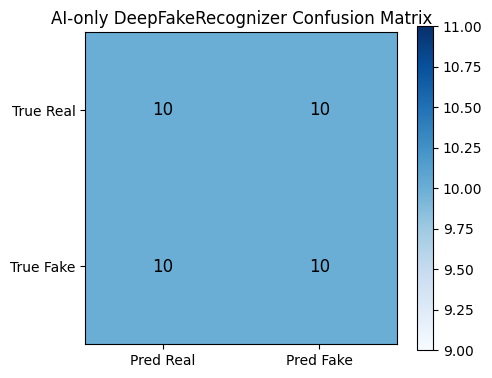

In [19]:
y_true = results_df['y_true'].astype(int).to_numpy()
y_pred = results_df['pred'].astype(int).to_numpy()
y_score = results_df['score'].astype(float).to_numpy()

metrics = {
    'accuracy': float(accuracy_score(y_true, y_pred)),
    'precision': float(precision_score(y_true, y_pred, zero_division=0)),
    'recall': float(recall_score(y_true, y_pred, zero_division=0)),
    'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    'roc_auc': float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else float('nan'),
}

print('AI-only DeepFakeRecognizer metrics:')
print(json.dumps(metrics, indent=2))
print('')
print(classification_report(y_true, y_pred, target_names=['real', 'fake'], zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set(
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=['Pred Real', 'Pred Fake'],
    yticklabels=['True Real', 'True Fake'],
    title='AI-only DeepFakeRecognizer Confusion Matrix',
)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()